In [13]:
import sys
sys.path.insert(0, '../../')

import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
import deepssfp.dataloader as dataloader

def load_dataset(path, foldername, files = None, indices = None):
    #dataloader.download_data(url, foldername, path)
    path = os.path.normpath(path)
    path = path.split(os.sep)
    foldername = foldername.split(os.sep)
    
    filepath = Path(os.path.join(*path, *foldername), '')    
    if files is None:
        files = os.listdir(filepath)
        files.sort()

    #print('------------------------------------------------------')
    #for i in range(len(files)):
    #    print(files[i])

    if indices:
        files = [files[i] for i in indices]

    print('------------------------------------------------------')
    for i in range(len(files)):
        print(files[i])

    dataset = [dataloader.read_rawdata(os.path.join(filepath, file)) for file in files]
    data_list = [data['data'] for data in dataset]

    for data in dataset:
        del data['data']

    M = np.stack(data_list, axis=-1)
    return M, dataset

In [14]:
path = 'F:/MRIData/2024'
folder = '20241028_T2map/dat_files'
M, datasets = load_dataset(path, folder, None, list(range(12)))
print(M.shape)
print(datasets[0]['dims'])

------------------------------------------------------
meas_MID163_bSSFP_knee_3D_AX1_PC0_5mmsl_130FOV_FID69817.dat
meas_MID166_bSSFP_knee_3D_AX1_PC30_5mmsl_130FOV_FID69820.dat
meas_MID168_bSSFP_knee_3D_AX1_PC60_5mmsl_130FOV_FID69822.dat
meas_MID170_bSSFP_knee_3D_AX1_PC90_5mmsl_130FOV_FID69824.dat
meas_MID172_bSSFP_knee_3D_AX1_PC120_5mmsl_130FOV_FID69826.dat
meas_MID174_bSSFP_knee_3D_AX1_PC150_5mmsl_130FOV_FID69828.dat
meas_MID176_bSSFP_knee_3D_AX1_PC180_5mmsl_130FOV_FID69830.dat
meas_MID178_bSSFP_knee_3D_AX1_PC210_5mmsl_130FOV_FID69832.dat
meas_MID180_bSSFP_knee_3D_AX1_PC240_5mmsl_130FOV_FID69834.dat
meas_MID182_bSSFP_knee_3D_AX1_PC270_5mmsl_130FOV_FID69836.dat
meas_MID184_bSSFP_knee_3D_AX1_PC300_5mmsl_130FOV_FID69838.dat
meas_MID186_bSSFP_knee_3D_AX1_PC330_5mmsl_130FOV_FID69840.dat
pymapVBVD version 0.4.8
Software version: VB


Scan 1/1, read all mdhs:   0%|          | 0.00/55.8M [00:00<?, ?B/s]

read data:   0%|          | 0/3328 [00:00<?, ?it/s]

pymapVBVD version 0.4.8
Software version: VB


Scan 1/1, read all mdhs:   0%|          | 0.00/55.8M [00:00<?, ?B/s]

...

read data:   0%|          | 0/3328 [00:00<?, ?it/s]

pymapVBVD version 0.4.8
Software version: VB


Scan 1/1, read all mdhs:   0%|          | 0.00/55.8M [00:00<?, ?B/s]

read data:   0%|          | 0/3328 [00:00<?, ?it/s]

(26, 128, 128, 12)
['Par', 'Lin', 'Col']


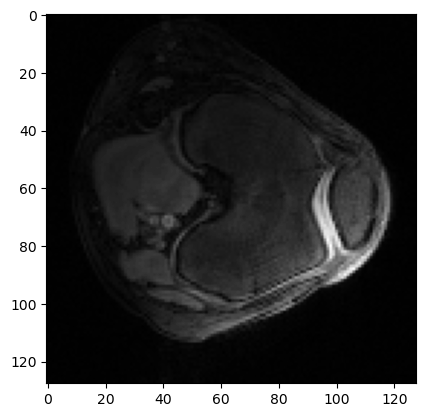

In [15]:
MSOS = np.sqrt(np.sum(M**2, axis=3))
plt.imshow(np.abs(MSOS[15, :, :]), cmap='gray')

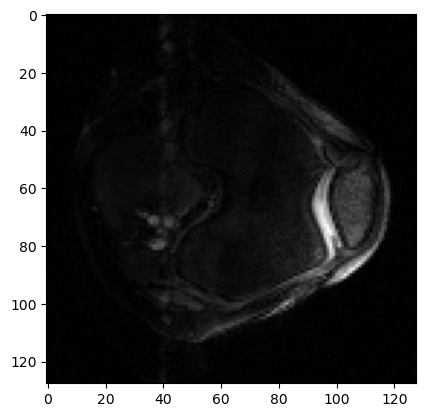

In [16]:
plt.imshow(np.abs(M[15, :, :, 6]), cmap='gray')

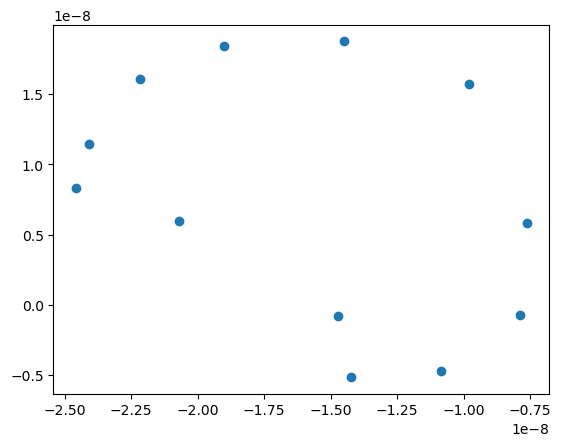

In [ ]:
M0 = M[10, 60, 100, :]
rr = np.real(M0)
ii = np.imag(M0)
plt.scatter(rr, ii)
plt.show()

In [18]:
path = 'F:/MRIData/2024'
folder = '20240327_HV_T2map/dat_files'
M, datasets = load_dataset(path, folder, None, [0,1,2,3,4,5,6,7,8,9,16,17])
print(M.shape)
print(datasets[0]['dims'])

------------------------------------------------------
meas_MID101_bSSFP_knee_3D_AX1_PC60_FID60949.dat
meas_MID103_bSSFP_knee_3D_AX1_PC90_FID60951.dat
meas_MID105_bSSFP_knee_3D_AX1_PC120_FID60953.dat
meas_MID107_bSSFP_knee_3D_AX1_PC150_FID60955.dat
meas_MID109_bSSFP_knee_3D_AX1_PC180_FID60957.dat
meas_MID111_bSSFP_knee_3D_AX1_PC210_FID60959.dat
meas_MID113_bSSFP_knee_3D_AX1_PC240_FID60961.dat
meas_MID115_bSSFP_knee_3D_AX1_PC270_FID60963.dat
meas_MID117_bSSFP_knee_3D_AX1_PC300_FID60965.dat
meas_MID119_bSSFP_knee_3D_AX1_PC330_FID60967.dat
meas_MID97_bSSFP_knee_3D_AX1_PC0_FID60945.dat
meas_MID99_bSSFP_knee_3D_AX1_PC30_FID60947.dat
pymapVBVD version 0.4.8
Software version: VB


Scan 1/1, read all mdhs:   0%|          | 0.00/273M [00:00<?, ?B/s]

read data:   0%|          | 0/16383 [00:00<?, ?it/s]

pymapVBVD version 0.4.8
Software version: VB


Scan 1/1, read all mdhs:   0%|          | 0.00/273M [00:00<?, ?B/s]

...

read data:   0%|          | 0/16383 [00:00<?, ?it/s]

pymapVBVD version 0.4.8
Software version: VB


Scan 1/1, read all mdhs:   0%|          | 0.00/273M [00:00<?, ?B/s]

read data:   0%|          | 0/16383 [00:00<?, ?it/s]

(128, 128, 128, 12)
['Par', 'Lin', 'Col']


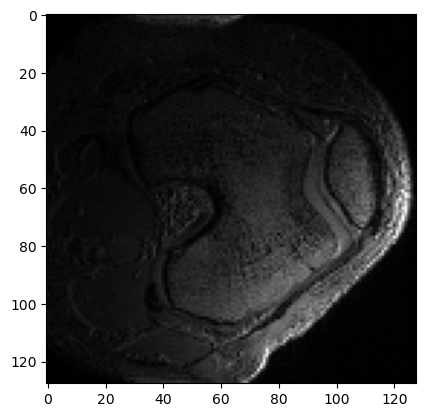

In [19]:
MSOS = np.sqrt(np.sum(M**2, axis=3))
plt.imshow(np.abs(MSOS[64, :, :]), cmap='gray')

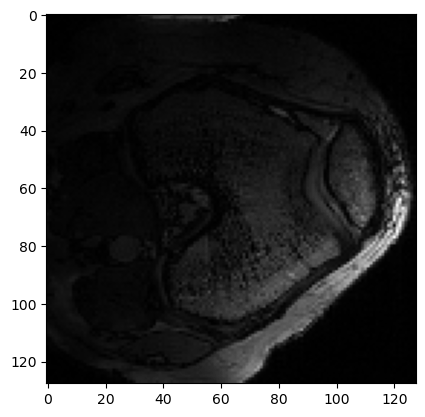

In [22]:
plt.imshow(np.abs(M[64, :, :, 6]), cmap='gray')

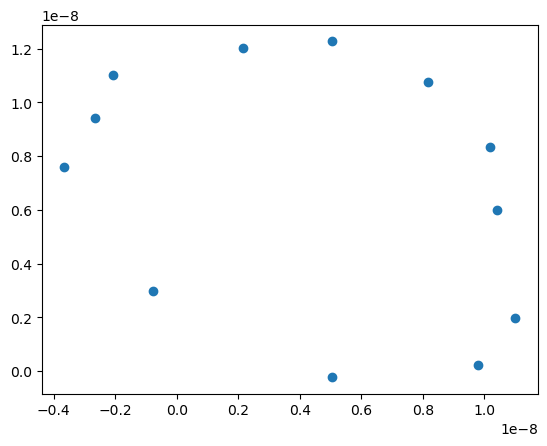

In [23]:
M0 = M[64, 60, 100, :]
rr = np.real(M0)
ii = np.imag(M0)
plt.scatter(rr, ii)
plt.show()